<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage3/Day_1/Day1_Lab1_PyTorch_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](https://i.imgur.com/a3uAqnb.png)

# Pytorch Basics
---

# **📌 How Data is Represented in Deep Learning?**

Deep learning models process data in the form of **tensors** (multi-dimensional arrays).  
The shape of the tensor depends on the type of data being used.

## **🔹 1️⃣ Tabular Data (Structured Data)**
- **Shape:** `(batch_size, features)`
- Each **row** is a sample, and each **column** is a feature.
- **Handled by:** `nn.Linear` (Fully Connected Layers).

## **🔹 2️⃣ Image Data (Computer Vision)**
- **Shape:** `(batch_size, channels, height, width)`
  - **RGB Image:** `channels = 3` (Red, Green, Blue).
  - **Grayscale Image:** `channels = 1` (sometimes omitted).
- **Handled by:** `nn.Conv2d` (Convolutional Layers).

| **Data Type** | **Tensor Shape** | **Handled by** |
|--------------|-----------------|---------------|
| **Tabular Data** | `(batch_size, features)` | `nn.Linear` |
| **Image Data** | `(batch_size, channels, height, width)` | `nn.Conv2d` |

✅ Each data type has a specific tensor representation and requires different processing techniques.


# **📌 How to Change the Dimensions in PyTorch?**

Manipulating tensor shapes is essential in deep learning. PyTorch provides several functions to modify tensor dimensions.

## **🔹 1️⃣ Flatten**
- Converts **any shape** to `(batch_size, features)`.
- **Example:**  
  `(batch_size, channels, height, width) → (batch_size, features)`

## **🔹 2️⃣ Squeeze**
- **Removes dimensions** with size `1`.
- **Example:**  
  `(1, 32, 3, 28, 28) → (32, 3, 28, 28)`

## **🔹 3️⃣ Unsqueeze**
- **Adds a dimension** with size `1` at a specified position.
- **Example:**  
  `(3, 28, 28) → (1, 3, 28, 28)`

## **🔹 4️⃣ Permute**
- **Reorders the dimensions** of a tensor by specifying the **new order of indices**.
- **Example:**  
  `(32, 28, 28, 3) → permute(0, 3, 1, 2) → (32, 3, 28, 28)`

## **🔹 5️⃣ View (works similar to reshape)**
- **Reshapes a tensor freely** while maintaining the same number of elements.
- **Example:**  
  `(32, 28, 28, 3) → view(-1, 28*28*3) → `(32, 28*28*3)`

| **Operation** | **Function** | **Purpose** | **Example Transformation** |
|--------------|-------------|-------------|----------------------------|
| **Flatten** | `.flatten()` | Convert tensor to (batch, features) | `(32, 3, 28, 28) → (32, 3*28*28)` |
| **Squeeze** | `.squeeze()` | Remove dims of size 1 | `(1, 3, 28, 28) → (3, 28, 28)` |
| **Unsqueeze** | `.unsqueeze(dim)` | Add a dim of size 1 | `(3, 28, 28) → (1, 3, 28, 28)` |
| **Permute** | `.permute(dims)` | Change order of dimensions | `(32, 28, 28, 3) → (32, 3, 28, 28)` |
| **View** | `.view(shape)` | Reshape freely | `(32, 28, 28, 3) → (32, 28*28*3)` |


In [ ]:
import torch

# 1️⃣ Flatten - Convert any shape to (batch_size, features)
x = torch.randn(32, 3, 28, 28)
x_flat = x.flatten(start_dim=1)
print("Flatten:", x_flat.shape)  # (32, 2352)

# 2️⃣ Squeeze - Remove dimensions with size 1
x = torch.randn(1, 3, 28, 28)
x_sq = x.squeeze()
print("Squeeze:", x_sq.shape)  # (3, 28, 28)

# 3️⃣ Unsqueeze - Add a new dimension of size 1
x = torch.randn(3, 28, 28)
x_unsq = x.unsqueeze(0)
print("Unsqueeze:", x_unsq.shape)  # (1, 3, 28, 28)

# 4️⃣ Permute - Reorder dimensions
x = torch.randn(32, 28, 28, 3)  # (batch, height, width, channels)
x_perm = x.permute(0, 3, 1, 2)  # (batch, channels, height, width)
print("Permute:", x_perm.shape)  # (32, 3, 28, 28)

# 5️⃣ View - Reshape freely while keeping same number of elements
x = torch.randn(32, 28, 28, 3)
x_view = x.view(32, -1)  # Flatten all except batch
print("View:", x_view.shape)  # (32, 28*28*3)


Flatten: torch.Size([32, 2352])
Squeeze: torch.Size([3, 28, 28])
Unsqueeze: torch.Size([1, 3, 28, 28])
Permute: torch.Size([32, 3, 28, 28])
View: torch.Size([32, 2352])


### 🔹 Changing Data Type or Moving Data/Model to CPU/GPU  

PyTorch allows you to **change the datatype** of a tensor and **move it between CPU and GPU** using `.to()`.  

---

### ✅ **Change Datatype**
Use `.to(dtype)` to convert a tensor's data type.

In [ ]:
import torch

# Create a float32 tensor
x = torch.tensor([1.2, 2.3, 3.4], dtype=torch.float32)
print(x.dtype)  # Output: torch.float32

# Convert to float16
x_half = x.to(torch.float16)
print(x_half.dtype)  # Output: torch.float16

torch.float32
torch.float16


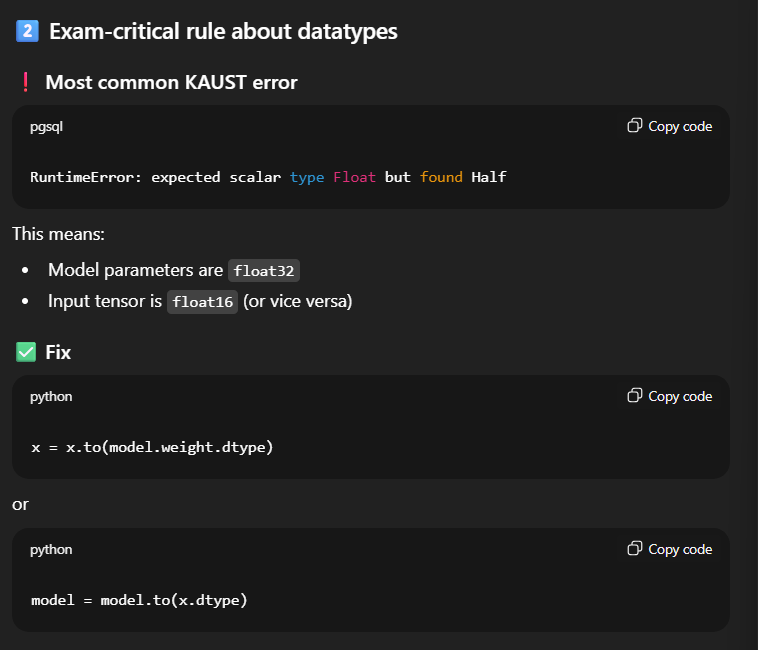

### ✅ **Move Tensors to GPU (if available)**
Use `.to(device)` to move a tensor to GPU for faster computation.

**GPUs are faster and more efficient** in most cases when training or inferencing deep learning models.  


In [ ]:
# Automatically select CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a tensor and move it to GPU
x_gpu = x.to(device)
print(x_gpu.device)  # Output: cuda:0 (if GPU is available) or cpu

cpu


Note: When training a model, always move BOTH the model and data to the same device. Otherwise, you will get an error like this:

`RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!`

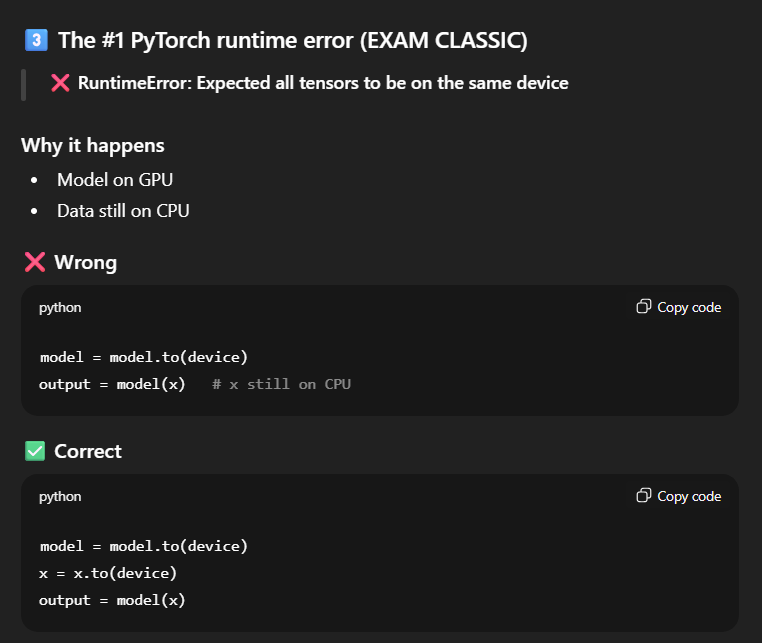

### 🧠 AI Layers

PyTorch provides various **neural network layers** to build deep learning models. Below are some of the most commonly used layers.

---

## 🔹 1️⃣ Linear Layer (`nn.Linear`)

### 📌 **Usage**
1. Used for **fully connected layers** (Dense layers).
2. Typically used as the **final layer** in CNNs for classification.

In [ ]:
# Example

import torch
import torch.nn as nn

# Define a Linear layer
linear_layer = nn.Linear(in_features=5, out_features=3)
# Weight matrix shape = (3, 5)
# Bias shape = (3,)

# Random input tensor (batch_size=16, in_features=5)
x = torch.randn(16, 5)

# Forward pass
output = linear_layer(x)

print("Input Shape:", x.shape)       # (16, 5)
print("Output Shape:", output.shape)  # (16, 3) (batch_size, out_features)

Input Shape: torch.Size([16, 5])
Output Shape: torch.Size([16, 3])


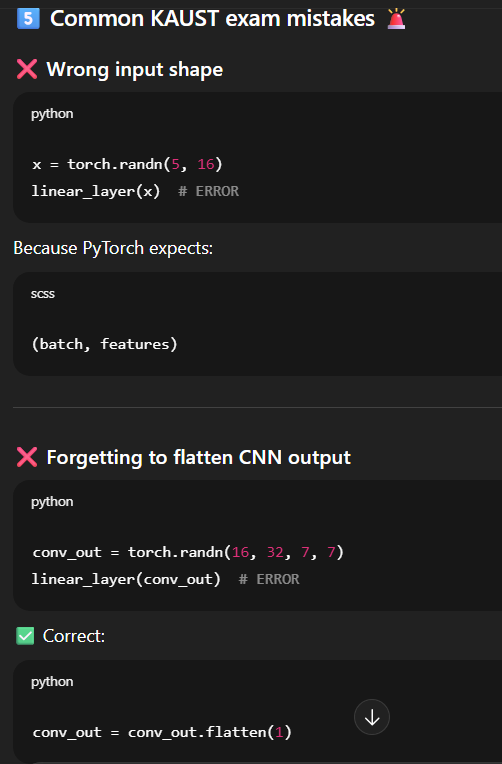

## 🔹 2️⃣ Convolutional Layer (`nn.Conv2d`)


###  📌 **Usage**
✅ `nn.Conv2d` is used for **feature extraction** in images.  
🚫 It **does not perform classification or regression**—you need a `nn.Linear` layer for that.  


In [ ]:
# Example

import torch
import torch.nn as nn

# Define a Conv2D layer
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
# in_channels=3 --> RGB image (3 channels)
# out_channels=16 --> 16 different filters → 16 feature maps
# kernel_size=3 --> 3×3 sliding window


# Random input tensor (batch_size=16, channels=3, height=32, width=32)
x = torch.randn(16, 3, 32, 32)

# Forward pass
output = conv_layer(x)

print("Input Shape:", x.shape)       # (16, 3, 32, 32)
print("Output Shape:", output.shape)  # (16, 16, 30, 30)


Input Shape: torch.Size([16, 3, 32, 32])
Output Shape: torch.Size([16, 16, 30, 30])


# **📌 Important Note**
When you use **Convolutional layers (`nn.Conv2d`)**, the **output channels tend to be larger** than the input channels (unlike `nn.Linear`).  

### **Why?**
- Each convolutional layer **extracts more useful features** from the input.
- As more filters are applied, the **number of channels increases**.
- Meanwhile, **spatial size (height & width) decreases**.

✅ **This allows the model to capture richer features while reducing unnecessary spatial details.**


The **output image size** after a convolutional layer is calculated using the formula (or you can get it by trial-and-error):

![image.png](https://i.imgur.com/8XKBFBU.jpeg)

## 🔹 3️⃣ Pooling (`nn.MaxPool2d` / `nn.AvgPool2d`)**

###  📌 **Usage**
- **Reduces spatial dimensions** (height & width) while retaining important features.
- Typically used **after Conv2D layers** to downsample feature maps.

In [ ]:
import torch
import torch.nn as nn

# Define layers
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
relu = nn.ReLU()    ## An old friend ;)     Do you remember why do we need it here? ReLU introduces non-linearity, Without ReLU: CNN becomes a linear function, Cannot learn complex patterns
pool = nn.MaxPool2d(kernel_size=2, stride=2)

# Sample input tensor (batch_size=2, channels=3, height=32, width=32)
x = torch.randn(2, 3, 32, 32)

# 🔹 Step 1: Convolution
x = conv(x)
print("After Conv2D:", x.shape)  # (2, 16, 32, 32)

# 🔹 Step 2: ReLU Activation
x = relu(x)
print("After ReLU:", x.shape)  # (2, 16, 32, 32)

# 🔹 Step 3: Pooling (Reduces spatial size)
x = pool(x)
print("After Pooling:", x.shape)  # (2, 16, 16, 16)

After Conv2D: torch.Size([2, 16, 32, 32])
After ReLU: torch.Size([2, 16, 32, 32])
After Pooling: torch.Size([2, 16, 16, 16])


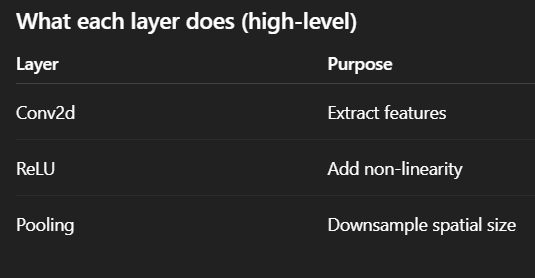

### **But wait a minute, if Conv2D extracts the features only, how should we do the classification/regression? 🤔**

Conv2D layers are responsible for extracting features (edges, textures, patterns, etc.) from the input data, but they **do not perform classification or regression directly**.  

To classify or predict, we need to **map the extracted features** to the desired output using **fully connected layers (`nn.Linear`)** after flattening the feature maps.

---

### **🏗️ CNN Structure Example**
A typical CNN model for classification or regression follows this pattern:

1️⃣ **`nn.Conv2d`** → Extracts features .  
2️⃣ **`nn.MaxPool2d`** → Reduces feature map size to focus on important information.  
3️⃣ **`nn.Conv2d`** → Extracts more features.  

... Add more layers if you want

4️⃣ **Flatten & `nn.Linear`** → Maps extracted features to output classes or predictions.


![image.png](https://i.imgur.com/fwNdXJs.jpeg)


---

### **🔹 Example: Classification with CNN**
| **Layer**                  | **Purpose**                        | **Example Shape Transformation** |
|----------------------------|-------------------------------------|-----------------------------------|
| **Input Image**            | Raw input                          | `(batch_size, channels, height, width)` |
| **`nn.Conv2d`**            | Extract features                   | `(32, 3, 32, 32) → (32, 16, 30, 30)` |
| **`nn.MaxPool2d`**         | Downsample feature maps            | `(32, 16, 30, 30) → (32, 16, 15, 15)` |
| **`nn.Conv2d`**            | Extract more features              | `(32, 16, 15, 15) → (32, 32, 13, 13)` |
| **Flatten**                | Prepare for fully connected layers | `(32, 32, 13, 13) → (32, 32*13*13)` |
| **`nn.Linear`**            | Map features to classes/predictions| `(32, 32*13*13) → (32, 10)` (for 10 classes) |




In [ ]:
import torch
import torch.nn as nn

# Define layers
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)  # Conv2D layer
# Input channels = 3 (RGB)
# Output channels = 16 (16 filters → 16 feature maps)
# kernel_size=3, default stride=1, default padding=0
# So spatial shrinks: 32 → 30

relu = nn.ReLU()  # Activation function
pool = nn.MaxPool2d(kernel_size=2)  # Pooling layer
flatten = nn.Flatten()  # Flatten layer to prepare for Linear
linear = nn.Linear(16 * 15 * 15, 10)  # Fully connected layer for classification (10 classes)
softmax = nn.Softmax(dim=1)  # ## Another old friend ;)

# Sample input tensor (batch_size=2, channels=3, height=32, width=32)
x = torch.randn(2, 3, 32, 32)

# 🔹 Step 1: Convolution
x = conv(x)
print("After Conv2D:", x.shape)  # (2, 16, 30, 30)

# 🔹 Step 2: ReLU Activation
x = relu(x)
print("After ReLU:", x.shape)  # (2, 16, 30, 30)

# 🔹 Step 3: Pooling (Reduces spatial size)
x = pool(x)
print("After Pooling:", x.shape)  # (2, 16, 15, 15)

# 🔹 Step 4: Flatten (Convert to batch_size, features)
x = flatten(x)
print("After Flatten:", x.shape)  # (2, 16*15*15)

# 🔹 Step 5: Fully Connected Layer
x = linear(x)
print("After Linear (Logits):", x.shape)  # (2, 10) → 10 values, one per class

# 🔹 Step 6: Softmax (Convert logits to probabilities)
x = softmax(x)
print("After Softmax (Probabilities):", x[0])  # Probabilities for each class


After Conv2D: torch.Size([2, 16, 30, 30])
After ReLU: torch.Size([2, 16, 30, 30])
After Pooling: torch.Size([2, 16, 15, 15])
After Flatten: torch.Size([2, 3600])
After Linear (Logits): torch.Size([2, 10])
After Softmax (Probabilities): tensor([0.1071, 0.0428, 0.1899, 0.0634, 0.1217, 0.0946, 0.1109, 0.1251, 0.0746,
        0.0697], grad_fn=<SelectBackward0>)


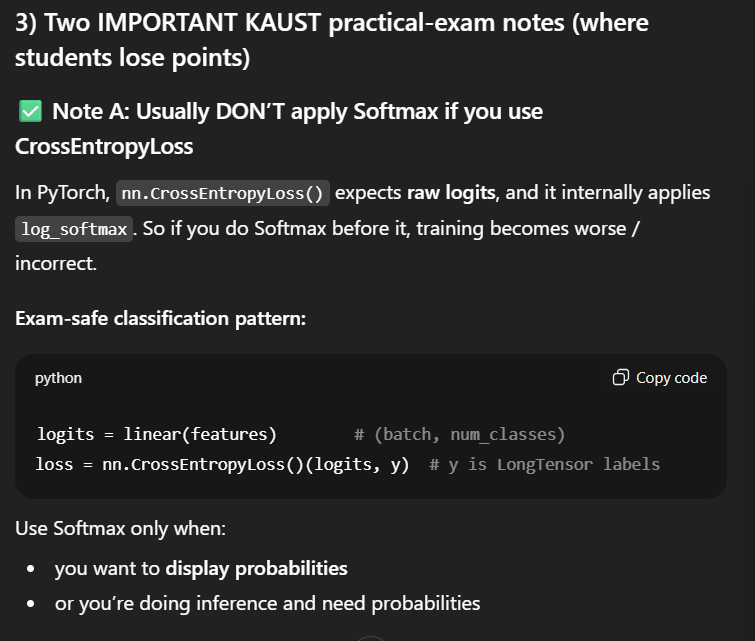

In [ ]:
# import torch
# import torch.nn as nn

# # 🔹 Layers
# conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
# relu = nn.ReLU()  # Activation function
# pool = nn.MaxPool2d(kernel_size=2)  # Pooling layer
# gap = nn.AdaptiveAvgPool2d((1, 1))  # Fix spatial size
# flatten = nn.Flatten()  # Prepare for Linear
# linear = nn.Linear(16, 10)  # 10 classes

# # 🔹 Loss function
# criterion = nn.CrossEntropyLoss()

# # 🔹 Sample input & labels
# x = torch.randn(2, 3, 32, 32)       # batch_size=2
# y = torch.tensor([2, 7])            # class labels (MUST be LongTensor)

# # 🔹 Step 1: Convolution
# x = conv(x)
# print("After Conv2D:", x.shape)     # (2, 16, 30, 30)

# # 🔹 Step 2: ReLU
# x = relu(x)
# print("After ReLU:", x.shape)       # (2, 16, 30, 30)

# # 🔹 Step 3: Pooling
# x = pool(x)
# print("After Pooling:", x.shape)    # (2, 16, 15, 15)

# # 🔹 Step 4: Adaptive Avg Pooling
# x = gap(x)
# print("After GAP:", x.shape)        # (2, 16, 1, 1)

# # 🔹 Step 5: Flatten
# x = flatten(x)
# print("After Flatten:", x.shape)    # (2, 16)

# # 🔹 Step 6: Linear layer (LOGITS)
# logits = linear(x)
# print("After Linear (Logits):", logits.shape)  # (2, 10)

# # 🔹 Step 7: Loss computation (NO Softmax!)
# loss = criterion(logits, y)
# print("Loss:", loss.item())

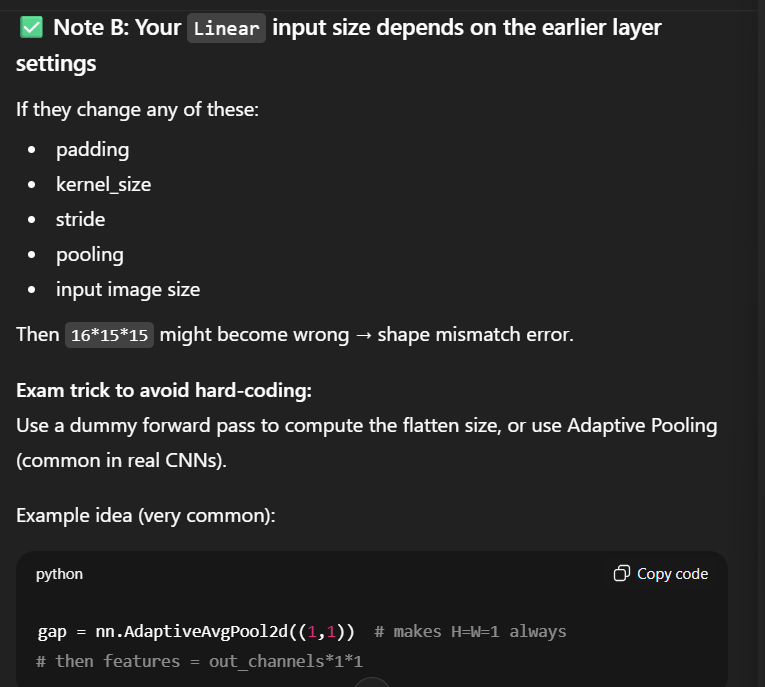

In [ ]:
# gap = nn.AdaptiveAvgPool2d((1,1))  # makes H=W=1 always
# then features = out_channels*1*1

# You add nn.AdaptiveAvgPool2d((1,1)) right before Flatten and Linear

# ====================================================================================

# import torch
# import torch.nn as nn

# # 🔹 Layers
# conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
# relu = nn.ReLU()  # Activation function
# pool = nn.MaxPool2d(kernel_size=2)  # Pooling layer
# gap = nn.AdaptiveAvgPool2d((1, 1))  # 🔥 Fix spatial size
# flatten = nn.Flatten()  # Flatten layer to prepare for Linear
# linear = nn.Linear(16, 10)  # Fully connected layer (10 classes)
# softmax = nn.Softmax(dim=1)  # ## Another old friend ;)

# # 🔹 Sample input tensor (batch_size=2, channels=3, height=32, width=32)
# x = torch.randn(2, 3, 32, 32)

# # 🔹 Step 1: Convolution
# x = conv(x)
# print("After Conv2D:", x.shape)
# # (2, 16, 30, 30)

# # 🔹 Step 2: ReLU Activation
# x = relu(x)
# print("After ReLU:", x.shape)
# # (2, 16, 30, 30)

# # 🔹 Step 3: Pooling (Reduces spatial size)
# x = pool(x)
# print("After Pooling:", x.shape)
# # (2, 16, 15, 15)

# # 🔹 Step 4: Adaptive Average Pooling
# x = gap(x)
# print("After AdaptiveAvgPool:", x.shape)
# # (2, 16, 1, 1)

# # 🔹 Step 5: Flatten (Convert to batch_size, features)
# x = flatten(x)
# print("After Flatten:", x.shape)
# # (2, 16)

# # 🔹 Step 6: Fully Connected Layer (Logits)
# x = linear(x)
# print("After Linear (Logits):", x.shape)
# # (2, 10)

# # 🔹 Step 7: Softmax (Convert logits to probabilities)
# x = softmax(x)
# print("After Softmax (Probabilities):", x[0])


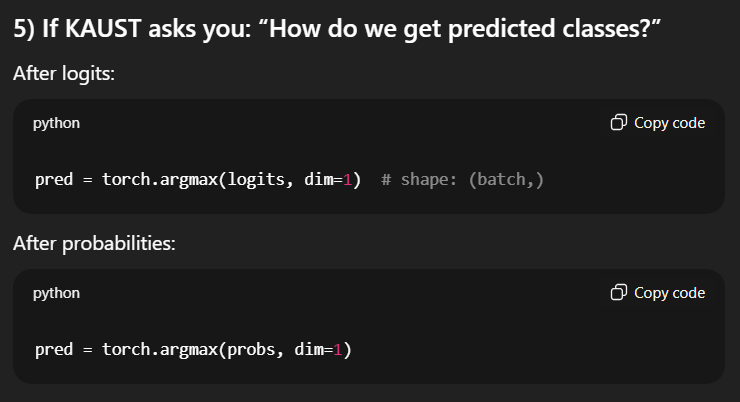

In [ ]:
# pred = torch.argmax(logits, dim=1)  # shape: (batch,)
# pred = torch.argmax(probs, dim=1)

# **Great! Now you know how to build a CNN model!**

However, PyTorch has a specific structure to organize your workflow.

---

## **📌 PyTorch Workflow Organization**

### **It consists of 4 main components:**
1️⃣ **Dataset Class**  
- Handles loading and preprocessing data.  
- Converts raw data (e.g., images, CSVs) into model-ready tensors.  

2️⃣ **Model Class**  
- Defines the architecture of your neural network (e.g., layers, activations).  

3️⃣ **Training Loop**  
- Updates model weights using backpropagation and optimizers.  
- Computes the loss for every batch and adjusts the parameters to minimize it.  

4️⃣ **Validation Loop**  
- Evaluates the model's performance on a validation set.  
- Does not update weights but computes metrics like accuracy or loss.  

---

### **📌 Note:**
All the labs will follow this structure. You will just modify the content for different tasks, such as changing datasets, architectures, or loss functions.

# **📌 Dataset Class**

- The **Dataset Class** is designed to **load and preprocess only one sample** at a time.
- The **DataLoader** uses the Dataset Class to load **multiple samples (batches)**.

Dataset → one sample

DataLoader → batch of samples

## **1️⃣ It Could Be Ready-to-Use:**

In [ ]:
from torchvision.datasets import MNIST

train_dataset = MNIST(root="./data", train=True, download=True)
test_dataset = MNIST(root="./data", train=False, download=True)

# OR


from torchvision.datasets import CIFAR10

train_dataset = CIFAR10(root="./data", train=True, download=True)
test_dataset = CIFAR10(root="./data", train=False, download=True)

## **2️⃣ Or You Have to Define It Yourself (We will explore how to define it in another lab).**

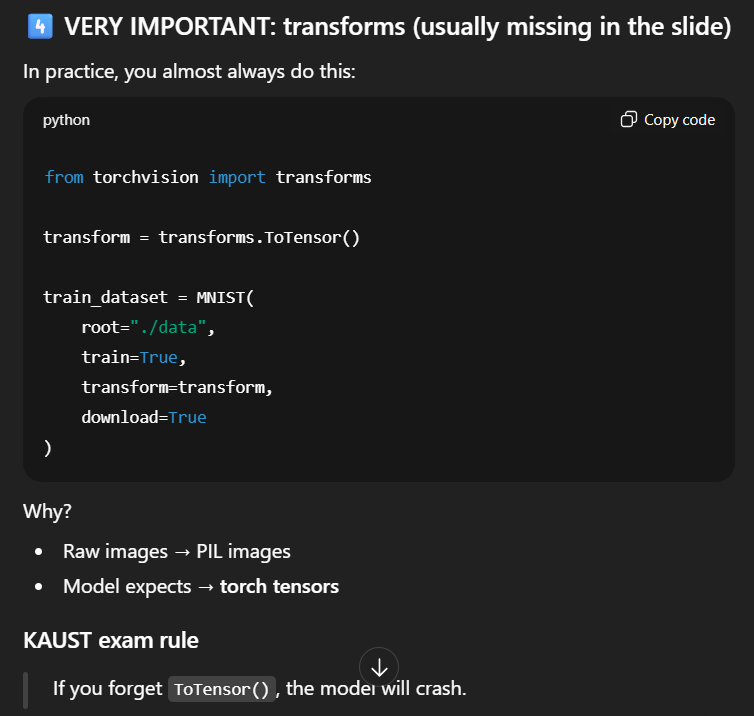

# **📌 Model Class**
---

## **📌 Key Components:**
1️⃣ **Define Layers (`__init__` method):**  
- Use PyTorch modules (e.g., `nn.Conv2d`, `nn.Linear`) to create the model's architecture.  

2️⃣ **Forward Pass (`forward` method):**  
- Specify how the input should be fed through the layers step by step.  

---

## **1️⃣ You may define It Yourself:**

In [ ]:
import torch
import torch.nn as nn

class CustomModel(nn.Module):
    def __init__(self):
        """
        1️⃣ Define all layers in the model.
        """
        super(CustomModel, self).__init__()

        # Convolutional Layer + Activation + Pooling
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layer
        self.fc = nn.Linear(16 * 16 * 16, 10)  # Output 10 classes

        # Softmax Layer
        self.softmax = nn.Softmax(dim=1)  # Apply along the class dimension

    def forward(self, x):
        """
        2️⃣ Define the forward pass (how data flows through the model).
        """
        x = self.conv1(x)  # Convolution
        x = self.relu(x)  # Activation
        x = self.pool(x)  # Pooling
        x = torch.flatten(x, start_dim=1)  # Flatten for FC layer
        x = self.fc(x)  # Fully connected layer
        x = self.softmax(x)  # Convert logits to probabilities
        return x  # Returns probability distribution


###
## **2️⃣ Or It Could Be Given Ready-to-Use (Will explore in another lab):**

In [ ]:
# Example
import torchvision.models as models
model = models.resnet18(pretrained=True)

In [ ]:
# ========================================================================

In [ ]:
# 3️⃣ EXAM-CORRECT version of this model (recommended)
# ✅ Fix 1: Use AdaptiveAvgPool2d (no hard-coding)
# ✅ Fix 2: REMOVE Softmax from the model


import torch
import torch.nn as nn

class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()

        # Feature extractor
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

        # 🔥 Fix spatial size
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.fc = nn.Linear(16, 10)  # 10 classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.gap(x)              # (batch, 16, 1, 1)
        x = x.flatten(1)             # (batch, 16)

        logits = self.fc(x)          # RAW logits
        return logits


# اذا طلبوا crossEntropy
# What you do in the TRAINING LOOP:
# criterion = nn.CrossEntropyLoss()

# logits = model(x)      # raw outputs
# loss = criterion(logits, y)

# **📌 Training Loop**

## **What is the Training Loop?**
The **training loop** is responsible for **updating the model's weights** so that it learns to minimize the loss function.


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
  # model → your CNN / NN
  # dataloader → provides batches (images, labels)
  # criterion → loss function (e.g. CrossEntropyLoss)
  # optimizer → updates weights (e.g. Adam, SGD)
  # device → CPU or GPU

    model.train()  # Set model to training mode, you will understand why later
    total_loss = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)  # Move data to GPU if available


        outputs = model(images)  # Forward pass
        # Calls forward()
        # Produces logits (if using CrossEntropyLoss)

        loss = criterion(outputs, labels)  # Compute loss
        # Measures how wrong the model is
        # Single scalar value
        # 🧠 If using CrossEntropyLoss:
        # - outputs = raw logits
        # - labels = class indices (NOT one-hot)


        optimizer.zero_grad()  # Reset gradients (Gradients must be zeroed before backpropagation to avoid accumulation)
        loss.backward()  # Backpropagation (compute gradients)
        optimizer.step()  # Update model parameters

        # Collect the loss
        total_loss += loss.item()
        # Why .item()?
        # Converts tensor → Python float

    return total_loss / len(dataloader)  # Return average loss


# **📌 Validation Loop**

## **What is the Validation Loop?**
- The **validation loop** is used to **evaluate model performance** on unseen data.  
- Unlike the training loop, **it does NOT update the model’s weights**.  
- It helps track **loss and accuracy** to monitor model improvements.

In [ ]:
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode, you will understand why later
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()
            # Why still compute loss?
            # To monitor overfitting
            # To compare training vs validation loss

            # (Optional) Compute accuracy
            predictions = outputs.argmax(dim=1)  # Get class with highest probability
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  # Compute accuracy in percentage
    return avg_loss, accuracy


# **📌 Full Training Process in PyTorch**

Now that you understand the **Dataset Class, Model Class, Training Loop, and Validation Loop**, it's time to put everything together into a **full training process**.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

# 🔹 Load MNIST Dataset
transform = transforms.ToTensor()
train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



# Model
class CustomModel(nn.Module):
    def __init__(self):
        """
        1️⃣ Define all layers in the model.
        """
        super(CustomModel, self).__init__()

        # Convolutional Layer + Activation + Pooling
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layer
        self.fc = nn.Linear(16 * 14 * 14, 10)  # Output 10 classes

        # Softmax Layer
        self.softmax = nn.Softmax(dim=1)  # Apply along the class dimension

    def forward(self, x):
        """
        2️⃣ Define the forward pass (how data flows through the model).
        """
        x = self.conv1(x)  # Convolution
        x = self.relu(x)  # Activation
        x = self.pool(x)  # Pooling
        x = torch.flatten(x, start_dim=1)  # Flatten for FC layer
        x = self.fc(x)  # Fully connected layer
        x = self.softmax(x)  # Convert logits to probabilities
        return x  # Returns probability distribution



# Training and Validation Loops
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

def validate(model, dataloader, criterion, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total  # Return accuracy




# Run Training
model = CustomModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):  # Train for 5 epochs
    train_one_epoch(model, train_loader, criterion, optimizer, device)
    accuracy = validate(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}: Validation Accuracy = {accuracy:.2f}%")


Epoch 1: Validation Accuracy = 95.12%
Epoch 2: Validation Accuracy = 96.73%
Epoch 3: Validation Accuracy = 97.17%
Epoch 4: Validation Accuracy = 97.51%
Epoch 5: Validation Accuracy = 97.66%


In [ ]:
# 1) Fix the model: remove Softmax

class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(16 * 14 * 14, 10)  # logits for 10 classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        logits = self.fc(x)
        return logits  # ✅ return logits (NO softmax)


  # 2) Training loop stays basically the same (but I’ll make it explicit)
  def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()


# 3) Validation: argmax over logits (same as you did)
def validate(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total





![image.png](https://i.imgur.com/1xbDOQX.jpeg)

### Contributed by: Mohamed Eltayeb


KAUST@KFUPM26

baraa.zino